# ATS Score Prediction


In [ ]:
!pip install datasets deep-translator kagglehub matplotlib seaborn sentence-transformers torch

In [2]:
import os
import pickle
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sentence_transformers import SentenceTransformer
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42
TARGET_COLUMN = 'ats_score'

/home/kisara/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading

In [ ]:
# === Load Kaggle Dataset: Job Postings + Skills ===
df_postings = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "asaniczka/1-3m-linkedin-jobs-and-skills-2024",
    "job_summary.csv",
)

df_skills = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "asaniczka/1-3m-linkedin-jobs-and-skills-2024",
    "job_skills.csv",
)

print(f"Postings: {df_postings.shape}")
print(f"Skills:   {df_skills.shape}")

In [2]:
# === Merge Kaggle -> df_final (summary + skill) ===

location_kaggle_cache = "../dataset/dataset_ats_sample.csv"

if not os.path.exists(location_kaggle_cache):
    os.makedirs("../dataset", exist_ok=True)

    df_skills_grouped = (
        df_skills.groupby('job_link')['job_skills']
        .apply(lambda x: ', '.join(x.dropna()))
        .reset_index()
    )

    df_postings_sample = (
        df_postings.dropna(subset=['job_summary'])
        .sample(n=5000, random_state=RANDOM_STATE)
    )

    df_final = pd.merge(df_postings_sample, df_skills_grouped, on='job_link', how='left')
    df_final = df_final[['job_summary', 'job_skills']]
    df_final = df_final.rename(columns={'job_summary': 'summary', 'job_skills': 'skill'})
    df_final.to_csv(location_kaggle_cache, index=False)
else:
    df_final = pd.read_csv(location_kaggle_cache)

print(f"df_final: {df_final.shape}")
df_final.head()

df_final: (5000, 2)


,summary,skill
0,"Company Description\nCore-Mark, a Performance ...","Conveyor systems, Warehouse management control..."
1,"Diversity Statement\nAt Fluor, we are proud to...","Architectural, Revit, SketchUp, AutoCAD, MS Of..."
2,Dollar General Corporation has been delivering...,"Sales, Customer service, Cash register operati..."
3,"""They made it easier for me to live, breathe, ...","Nursing, Psychiatry, Psych Nurse, LPT, LVN, Te..."
4,Company Overview\nPrimal Pet Foods is a Fairfi...,"Warehouse operations, Leadership skills, ERP, ..."


In [3]:
# === Load HuggingFace Dataset: Resume + ATS Score ===

location_hf_cache = "../dataset/df_resume_ats.csv"

if not os.path.exists(location_hf_cache):
    dataset_hf = load_dataset("0xnbk/resume-ats-score-v1-en")
    dataset_hf.set_format(type="pandas")
    df_resume = dataset_hf['train'][:]
    os.makedirs("../dataset", exist_ok=True)
    df_resume.to_csv(location_hf_cache, index=False)
else:
    df_resume = pd.read_csv(location_hf_cache)

print(f"df_resume: {df_resume.shape}")
print(f"Kolom: {list(df_resume.columns)}")
df_resume.head()

df_resume: (5099, 3)
Kolom: ['text', 'ats_score', 'original_label']


,text,ats_score,original_label
0,SummaryI am seeking a position wherein I may u...,80.6,Good Fit
1,ProfileHighly motivated Sales Associate with e...,24.3,No Fit
2,SummaryHaving achieved a milestone of 7 years ...,53.9,Potential Fit
3,SummaryWireless communications engineer with e...,52.5,Potential Fit
4,SummaryData Entry experienced and adept at inp...,59.2,Potential Fit


In [3]:
# === Gabungkan Kaggle + HuggingFace -> df ===

location_merged = "../dataset/dataset_merged_full.csv"

if not os.path.exists(location_merged):
    n = min(len(df_final), len(df_resume))
    df_kaggle_sample = df_final.sample(n=n, random_state=RANDOM_STATE).reset_index(drop=True)
    df_hf_sample = df_resume.sample(n=n, random_state=RANDOM_STATE).reset_index(drop=True)

    df = pd.DataFrame({
        'resume_text': df_hf_sample['text'].values,
        'ats_score': df_hf_sample['ats_score'].values,
        'original_label': df_hf_sample['original_label'].values,
        'job_summary': df_kaggle_sample['summary'].values,
        'job_skills': df_kaggle_sample['skill'].values,
    })

    df['combined_text'] = df['resume_text'].fillna('') + ' [SEP] ' + df['job_summary'].fillna('')
    df.to_csv(location_merged, index=False)
else:
    df = pd.read_csv(location_merged)

print(f"Dataset gabungan: {df.shape}")
print(f"Kolom: {list(df.columns)}")
df.head()

Dataset gabungan: (5000, 6)
Kolom: ['resume_text', 'ats_score', 'original_label', 'job_summary', 'job_skills', 'combined_text']


,resume_text,ats_score,original_label,job_summary,job_skills,combined_text
0,SummaryTo obtain a position where my business ...,22.7,No Fit,"Description\nAt Torrid, we celebrate every sha...","Sales, Customer service, Fashion, Retail, Prom...",SummaryTo obtain a position where my business ...
1,Executive SummaryElectrical Engineer with the ...,27.1,No Fit,We are Wayfair; we deliver a best-in-class cus...,"Strong work ethic, English comprehension, Abil...",Executive SummaryElectrical Engineer with the ...
2,SummaryExperienced .NET developer with experie...,22.0,No Fit,Summary\nThe Leader in Training (LIT) and Floo...,"Sales, Merchandising, Operations, Customer ser...",SummaryExperienced .NET developer with experie...
3,Professional SummaryArdent and intelligent sof...,50.1,Potential Fit,MedPro Healthcare Allied Staffing is seeking a...,"MRI, Radiology, Radiography, Critical care, Ma...",Professional SummaryArdent and intelligent sof...
4,Professional SummarySOFTWARE ENGINEER with ove...,81.5,Good Fit,This position is affiliated with Landmark Sout...,"Nursing, Critical Care, Patient Experience, Pa...",Professional SummarySOFTWARE ENGINEER with ove...


## 2. Exploratory Data Analysis (EDA)

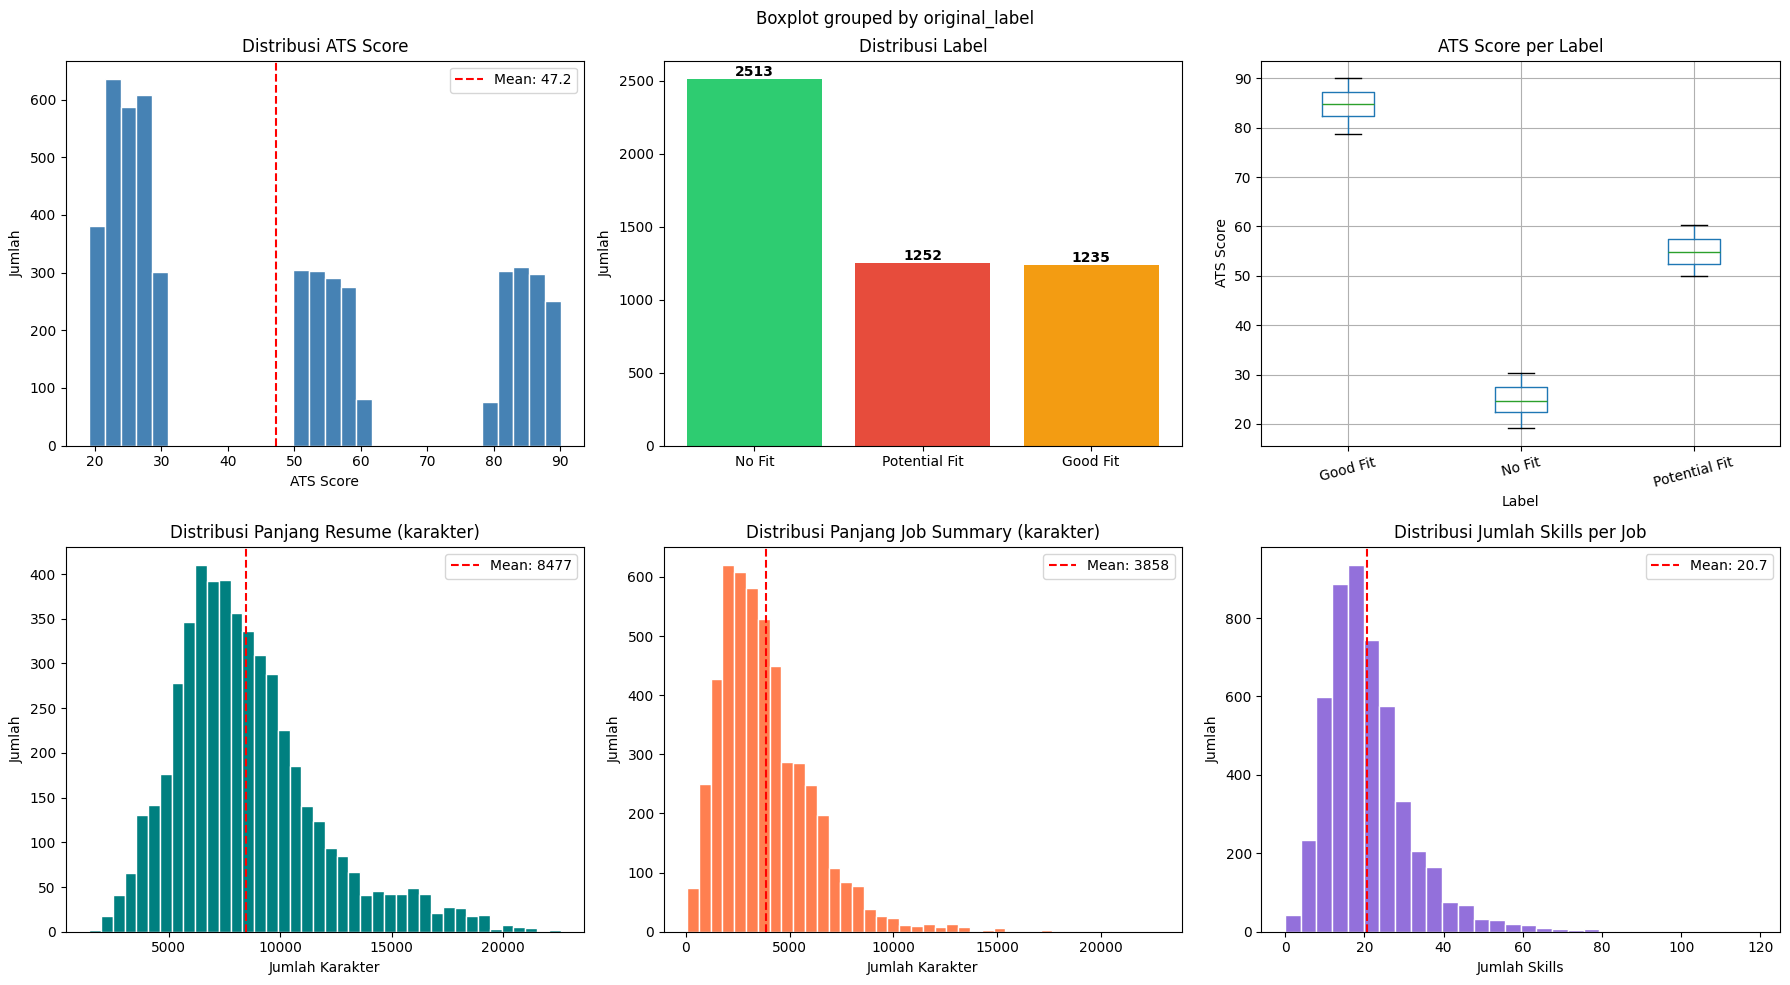

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis -- ATS Dataset', fontsize=16, fontweight='bold')

# 1. Distribusi ATS Score
ax = axes[0, 0]
ax.hist(df['ats_score'], bins=30, color='steelblue', edgecolor='white')
ax.set_title('Distribusi ATS Score')
ax.set_xlabel('ATS Score')
ax.set_ylabel('Jumlah')
ax.axvline(df['ats_score'].mean(), color='red', linestyle='--',
           label=f"Mean: {df['ats_score'].mean():.1f}")
ax.legend()

# 2. Distribusi Original Label
ax = axes[0, 1]
label_counts = df['original_label'].value_counts()
ax.bar(label_counts.index, label_counts.values, color=['#2ecc71', '#e74c3c', '#f39c12'])
ax.set_title('Distribusi Label')
ax.set_ylabel('Jumlah')
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')

# 3. Boxplot ATS Score per Label
ax = axes[0, 2]
df.boxplot(column='ats_score', by='original_label', ax=ax)
ax.set_title('ATS Score per Label')
ax.set_xlabel('Label')
ax.set_ylabel('ATS Score')
plt.sca(ax)
plt.xticks(rotation=15)

# 4. Panjang Resume Text
ax = axes[1, 0]
resume_len = df['resume_text'].fillna('').str.len()
ax.hist(resume_len, bins=40, color='teal', edgecolor='white')
ax.set_title('Distribusi Panjang Resume (karakter)')
ax.set_xlabel('Jumlah Karakter')
ax.set_ylabel('Jumlah')
ax.axvline(resume_len.mean(), color='red', linestyle='--',
           label=f"Mean: {resume_len.mean():.0f}")
ax.legend()

# 5. Panjang Job Summary
ax = axes[1, 1]
summary_len = df['job_summary'].fillna('').str.len()
ax.hist(summary_len, bins=40, color='coral', edgecolor='white')
ax.set_title('Distribusi Panjang Job Summary (karakter)')
ax.set_xlabel('Jumlah Karakter')
ax.set_ylabel('Jumlah')
ax.axvline(summary_len.mean(), color='red', linestyle='--',
           label=f"Mean: {summary_len.mean():.0f}")
ax.legend()

# 6. Jumlah Skills per Job
ax = axes[1, 2]
skill_count = df['job_skills'].fillna('').apply(lambda x: len(x.split(',')) if x.strip() else 0)
ax.hist(skill_count, bins=30, color='mediumpurple', edgecolor='white')
ax.set_title('Distribusi Jumlah Skills per Job')
ax.set_xlabel('Jumlah Skills')
ax.set_ylabel('Jumlah')
ax.axvline(skill_count.mean(), color='red', linestyle='--',
           label=f"Mean: {skill_count.mean():.1f}")
ax.legend()

plt.tight_layout()
plt.show()

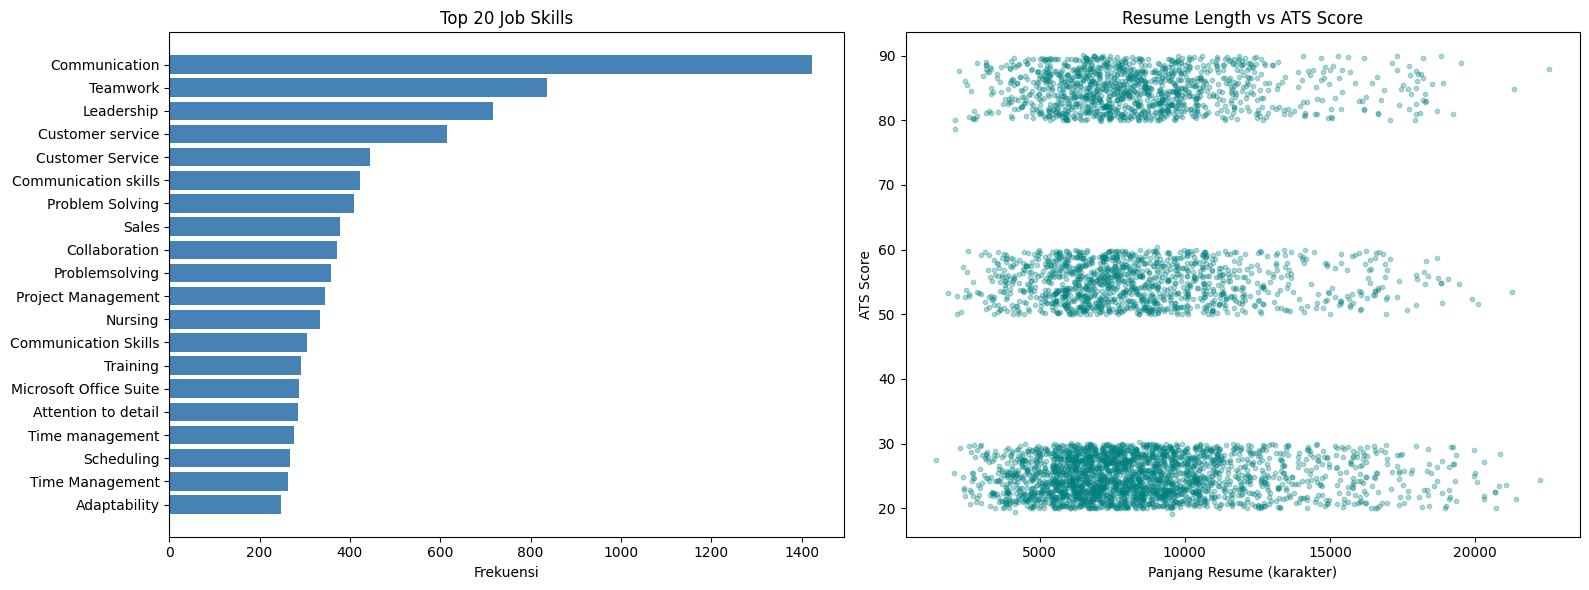

RINGKASAN DATASET
Total baris: 5000
Kolom: ['resume_text', 'ats_score', 'original_label', 'job_summary', 'job_skills', 'combined_text']

ATS Score:
  Mean:   47.20
  Median: 29.90
  Std:    24.96
  Min:    19.16
  Max:    90.05

Null per kolom:
resume_text       0
ats_score         0
original_label    0
job_summary       0
job_skills        9
combined_text     0
dtype: int64


In [6]:
# === EDA Tambahan: Top Skills + Scatter + Ringkasan ===

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 Skills
ax = axes[0]
all_skills = df['job_skills'].dropna().str.split(', ').explode()
top_skills = all_skills.value_counts().head(20)
ax.barh(top_skills.index[::-1], top_skills.values[::-1], color='steelblue')
ax.set_title('Top 20 Job Skills')
ax.set_xlabel('Frekuensi')

# Scatter: resume length vs ATS score
ax = axes[1]
resume_len = df['resume_text'].fillna('').str.len()
ax.scatter(resume_len, df['ats_score'], alpha=0.3, s=10, color='teal')
ax.set_title('Resume Length vs ATS Score')
ax.set_xlabel('Panjang Resume (karakter)')
ax.set_ylabel('ATS Score')

plt.tight_layout()
plt.show()

# Ringkasan statistik
print('=' * 50)
print('RINGKASAN DATASET')
print('=' * 50)
print(f'Total baris: {len(df)}')
print(f'Kolom: {list(df.columns)}')
print()
print('ATS Score:')
print(f'  Mean:   {df["ats_score"].mean():.2f}')
print(f'  Median: {df["ats_score"].median():.2f}')
print(f'  Std:    {df["ats_score"].std():.2f}')
print(f'  Min:    {df["ats_score"].min():.2f}')
print(f'  Max:    {df["ats_score"].max():.2f}')
print()
print('Null per kolom:')
print(df.isnull().sum())

## 3. Text Preprocessing Pipeline

In [4]:
def case_folding(text: str) -> str:
    """Case folding: konversi semua teks ke lowercase."""
    if pd.isna(text):
        return ''
    return str(text).lower()


def tokenize(text: str) -> list[str]:
    """Tokenizer: pecah teks menjadi list token (kata)."""
    if pd.isna(text) or not str(text).strip():
        return []
    tokens = re.findall(r'[a-zA-Z0-9+#]+', str(text).lower())
    return tokens


def remove_punctuation(text: str) -> str:
    """Hapus tanda baca dan karakter khusus."""
    if pd.isna(text):
        return ''
    cleaned = re.sub(r'[^a-zA-Z0-9\s+#.]', ' ', str(text))
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned

In [5]:
STOPWORDS_EN = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your',
    'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her',
    'hers', 'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs',
    'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those',
    'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had',
    'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if',
    'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with',
    'about', 'against', 'between', 'through', 'during', 'before', 'after', 'above',
    'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under',
    'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why',
    'how', 'all', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such',
    'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very',
    's', 't', 'can', 'will', 'just', 'don', 'should', 'now', 'd', 'll', 'm', 'o',
    're', 've', 'y', 'ain', 'aren', 'couldn', 'didn', 'doesn', 'hadn', 'hasn',
    'haven', 'isn', 'ma', 'mightn', 'mustn', 'needn', 'shan', 'shouldn', 'wasn',
    'weren', 'won', 'wouldn',
    'also', 'well', 'may', 'use', 'using', 'used', 'including', 'etc',
}


def remove_stopwords(tokens: list[str], stopwords: set[str] = STOPWORDS_EN) -> list[str]:
    """Stopwords removal: buang kata umum yang tidak bermakna."""
    return [t for t in tokens if t not in stopwords and len(t) > 1]

In [6]:
_SUFFIX_RULES = [
    ('ational', 'ate'), ('tional', 'tion'), ('enci', 'ence'), ('anci', 'ance'),
    ('izer', 'ize'), ('alli', 'al'), ('entli', 'ent'), ('eli', 'e'),
    ('ousli', 'ous'), ('ization', 'ize'), ('ation', 'ate'), ('ator', 'ate'),
    ('alism', 'al'), ('iveness', 'ive'), ('fulness', 'ful'), ('ousness', 'ous'),
    ('aliti', 'al'), ('iviti', 'ive'), ('biliti', 'ble'),
    ('ies', 'y'), ('ive', ''), ('ing', ''), ('ful', ''), ('ness', ''),
    ('ment', ''), ('tion', 't'), ('able', ''), ('ible', ''),
    ('ly', ''), ('ed', ''), ('er', ''), ('es', ''), ('s', ''),
]


def stem_word(word: str) -> str:
    """Simple suffix-stripping stemmer (inspired Porter)."""
    if len(word) <= 3:
        return word
    for suffix, replacement in _SUFFIX_RULES:
        if word.endswith(suffix) and len(word) - len(suffix) >= 2:
            return word[:-len(suffix)] + replacement
    return word


def stem_tokens(tokens: list[str]) -> list[str]:
    """Terapkan stemming pada list token."""
    return [stem_word(t) for t in tokens]

In [7]:
def preprocess_text(text: str) -> str:
    """Full pipeline: case folding -> punctuation removal -> tokenize -> stopword removal -> stemming."""
    folded = case_folding(text)
    cleaned = remove_punctuation(folded)
    tokens = tokenize(cleaned)
    filtered = remove_stopwords(tokens)
    stemmed = stem_tokens(filtered)
    return ' '.join(stemmed)


def preprocess_to_tokens(text: str) -> list[str]:
    """Sama seperti preprocess_text tapi mengembalikan list token."""
    folded = case_folding(text)
    cleaned = remove_punctuation(folded)
    tokens = tokenize(cleaned)
    filtered = remove_stopwords(tokens)
    return stem_tokens(filtered)

## 4. Feature Engineering -- TF-IDF Embedding

In [8]:
from scipy.sparse import hstack

# Preprocessing kolom teks
df['job_skills_clean'] = df['job_skills'].fillna('').apply(preprocess_text)
df['job_summary_clean'] = df['job_summary'].fillna('').apply(preprocess_text)
df['combined_clean'] = df['combined_text'].fillna('').apply(preprocess_text)

# TF-IDF pada job skills
skill_tfidf = TfidfVectorizer(max_features=200, ngram_range=(1, 2))
skill_emb = skill_tfidf.fit_transform(df['job_skills_clean'])

feat_names = skill_tfidf.get_feature_names_out()
skill_cols = [f'skill_tfidf_{n}' for n in feat_names]

df = pd.concat([
    df,
    pd.DataFrame(skill_emb.toarray(), columns=skill_cols, index=df.index),
], axis=1)

print(f'Kolom skill embedding: {len(skill_cols)}')
print(f'Total kolom: {len(df.columns)}')
print(f'Contoh kolom: {skill_cols[:10]}')

Kolom skill embedding: 200
Total kolom: 209
Contoh kolom: ['skill_tfidf_ability', 'skill_tfidf_ability work', 'skill_tfidf_account', 'skill_tfidf_act', 'skill_tfidf_adaptability', 'skill_tfidf_administrate', 'skill_tfidf_analysi', 'skill_tfidf_analytical', 'skill_tfidf_analytical skill', 'skill_tfidf_assess']


## 5. MiniLM Embedding -- paraphrase-multilingual-MiniLM-L12-v2

Embedding semantik menggunakan SentenceTransformer.
Model ini mendukung 50+ bahasa dan menghasilkan vektor 384-dimensi.

In [9]:
# === MiniLM Embedding ===
model_name = 'paraphrase-multilingual-MiniLM-L12-v2'
embedder = SentenceTransformer(model_name)

# Embed teks gabungan (resume + job) -> vektor 384-dimensi
texts = df['combined_clean'].tolist()
print(f'Menge-embed {len(texts)} teks dengan {model_name}...')
embeddings = embedder.encode(texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True)

print(f'Shape embedding: {embeddings.shape}')
print(f'Dimensi: {embeddings.shape[1]}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6252.98it/s]


Menge-embed 5000 teks dengan paraphrase-multilingual-MiniLM-L12-v2...


Batches: 100%|██████████| 157/157 [00:08<00:00, 18.04it/s]

Shape embedding: (5000, 384)
Dimensi: 384


## 6. Fine-Tuning -- MiniLM + Regression Head

Tuning MiniLM dengan regression head untuk ATS score prediction.
Hanya training head regressor, MiniLM backbone tetap (feature extractor).

Training 50 epochs...
  Epoch  10/50 | Train Loss: 622.1613 | Test Loss: 607.0382
  Epoch  20/50 | Train Loss: 601.0556 | Test Loss: 599.3670
  Epoch  30/50 | Train Loss: 602.6480 | Test Loss: 607.8574
  Epoch  40/50 | Train Loss: 589.5200 | Test Loss: 609.4411
  Epoch  50/50 | Train Loss: 584.6501 | Test Loss: 613.9040

Final: MAE=21.75 | RMSE=24.78


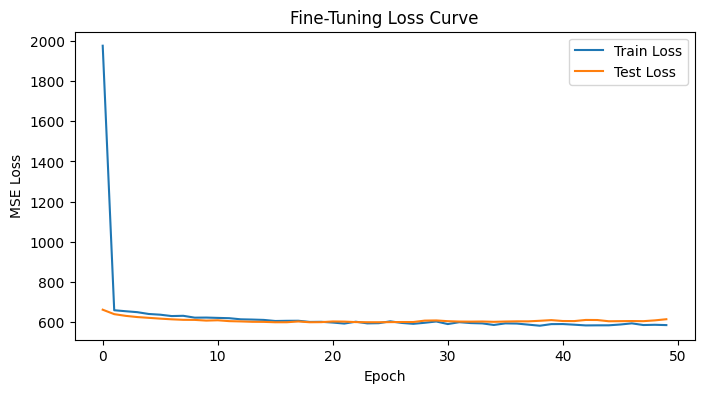

In [10]:
# === Fine-Tuning: MiniLM + Regression Head ===

# Konversi embedding + target ke tensor
X = torch.tensor(embeddings, dtype=torch.float32)
y = torch.tensor(df['ats_score'].values, dtype=torch.float32).unsqueeze(1)

# Split
n_test = int(0.2 * len(X))
indices = torch.randperm(len(X))
train_idx, test_idx = indices[n_test:], indices[:n_test]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Regression head sederhana
class RegressionHead(nn.Module):
    def __init__(self, input_dim=384, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)


model = RegressionHead(input_dim=embeddings.shape[1], hidden_dim=128)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 50
train_losses = []
test_losses = []

print(f'Training {epochs} epochs...')
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)
    train_losses.append(epoch_loss / len(train_dataset))

    model.eval()
    test_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            pred = model(batch_X)
            loss = criterion(pred, batch_y)
            test_loss += loss.item() * batch_X.size(0)
            all_preds.extend(pred.squeeze().tolist())
            all_targets.extend(batch_y.squeeze().tolist())
    test_losses.append(test_loss / len(test_dataset))

    if (epoch + 1) % 10 == 0:
        print(f'  Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f}')

# Final metrics
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
mae = mean_absolute_error(all_targets, all_preds)
rmse = root_mean_squared_error(all_targets, all_preds)
print(f'\nFinal: MAE={mae:.2f} | RMSE={rmse:.2f}')

# Plot loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train Loss')
ax.plot(test_losses, label='Test Loss')
ax.set_title('Fine-Tuning Loss Curve')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.show()

## Save MiniLM Regression Head

Simpan regression head dan metadata training agar model bisa dipakai ulang tanpa training ulang.

In [26]:
# === Save Model (pickle) ===

import pickle

os.makedirs('models', exist_ok=True)

MODEL_PATH = 'models/minilm_regressor.pkl'

bundle = {
    'model_state_dict': model.state_dict(),
    'input_dim': int(embeddings.shape[1]),
    'hidden_dim': 128,
    'activation': 'ReLU',
    'dropout_p': [0.2, 0.1],
    'output_dim': 1,
    # metadata
    'embedding_model': 'paraphrase-multilingual-MiniLM-L12-v2',
    'embedding_dim': int(embeddings.shape[1]),
    'head_architecture': 'MLP(384->128->64->1)',
    'optimizer': 'AdamW(lr=1e-3, weight_decay=1e-4)',
    'epochs': int(epochs),
    'train_loss': float(train_losses[-1]),
    'test_loss': float(test_losses[-1]),
    'mae': float(mae),
    'rmse': float(rmse),
}

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(bundle, f)

print(f'Saved → {MODEL_PATH} ({os.path.getsize(MODEL_PATH) / 1024:.0f} KB)')


Saved → models/minilm_regressor.pkl (227 KB)


## Load MiniLM Regression Head untuk Inference

In [ ]:

import pickle
import torch
import torch.nn as nn
from sentence_transformers import SentenceTransformer

MODEL_PATH = 'models/minilm_regressor.pkl'

with open(MODEL_PATH, 'rb') as f:
    bundle = pickle.load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class RegressionHead(nn.Module):
    def __init__(self, input_dim=384, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

embedder = SentenceTransformer(bundle['embedding_model'], device=str(device))

loaded_model = RegressionHead(
    input_dim=bundle['input_dim'],
    hidden_dim=bundle['hidden_dim'],
).to(device)
loaded_model.load_state_dict(bundle['model_state_dict'])
loaded_model.eval()

print(f'Loaded {MODEL_PATH}')
print(f'  Embedding: {bundle["embedding_model"]}')
print(f'  Head: {bundle["head_architecture"]}')
print(f'  Epochs: {bundle["epochs"]} | MAE: {bundle["mae"]:.2f} | RMSE: {bundle["rmse"]:.2f}')

# Quick smoke test
text = ['sample resume [SEP] sample job description']
emb = embedder.encode(text, convert_to_tensor=True).to(device)

with torch.no_grad():
    skor = loaded_model(emb).squeeze().item()

print(f'Smoke test ATS Score: {skor:.1f}')


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16275.06it/s]


Loaded models/minilm_regressor.pkl
  Embedding: paraphrase-multilingual-MiniLM-L12-v2
  Head: MLP(384->128->64->1)
  Epochs: 50 | MAE: 18.98 | RMSE: 21.93
Smoke test ATS Score: 61.9


## Inference Testing dengan Data Benaran

Ambil 5 sampel dari test set, bandingkan prediksi model tersimpan vs ground truth.
Pastikan notebook sudah dijalankan dari atas (ada `df`, `preprocess_text`, `X_test`, `y_test`).

In [28]:
# === Test Inference: Real Data ===

import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

N_SAMPLES = 5

# Ambil N sampel random dari test split
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=min(N_SAMPLES, len(X_test)), replace=False)

sample_texts = [X_test.iloc[i] for i in sample_idx]
sample_true = [y_test.iloc[i] for i in sample_idx]

# Encode + predict
sample_emb = embedder.encode(sample_texts, convert_to_tensor=True).to(device)

with torch.no_grad():
    sample_pred = loaded_model(sample_emb).squeeze().tolist()

print(f'  {"Actual":>6}   {"Predicted":>10}   {"Diff":>6}')
print(f'  {"-" * 6}   {"-" * 10}   {"-" * 6}')
for true, pred in zip(sample_true, sample_pred):
    print(f'  {true:6.1f}   {pred:10.1f}   {true - pred:+6.1f}')

# Predict seluruh test set
test_emb = embedder.encode(X_test.tolist(), convert_to_tensor=True, batch_size=64, show_progress_bar=True).to(device)
with torch.no_grad():
    test_pred = loaded_model(test_emb).squeeze().cpu().numpy()

mae_test = mean_absolute_error(y_test, test_pred)
rmse_test = root_mean_squared_error(y_test, test_pred)

print(f'\nFull test set ({len(y_test)} samples):')
print(f'  MAE:  {mae_test:.2f}')
print(f'  RMSE: {rmse_test:.2f}')

  Actual    Predicted     Diff
  ------   ----------   ------
    26.3         39.1    -12.8
    24.8         52.6    -27.8
    23.3         44.4    -21.1
    88.1         57.2    +30.9
    27.2         57.5    -30.3


Batches:  50%|█████     | 8/16 [00:00<00:00, 13.66it/s]

Batches: 100%|██████████| 16/16 [00:01<00:00, 13.64it/s]


Full test set (1000 samples):
  MAE:  21.17
  RMSE: 24.17


## Manual ATS Scoring -- Input Resume + Skills + Job Summary

Masukkan resume, skills, dan deskripsi lowongan secara bebas. Model akan memprediksi ATS Score.
Pastikan cell Load MiniLM (cell:25) sudah dijalankan terlebih dulu.

In [ ]:


resume_text = """
Senior Software Engineer with 5+ years of experience in backend development.
Expert in Python, Django, FastAPI, and microservices architecture.
Led a team of 4 engineers to build a real-time data pipeline processing 1M+ events/day.
"""

skills = "Python, Django, FastAPI, PostgreSQL, Docker, AWS, Redis, Kafka, CI/CD"

job_summary = """
We are looking for a Senior Backend Engineer to join our core platform team.
The ideal candidate has strong Python skills, experience with distributed systems,
and a track record of delivering scalable APIs. You will design and implement
microservices, optimize database queries, and mentor junior engineers.
 Required: 5+ years Python, experience with PostgreSQL, AWS, Docker.
"""

# --- PREPROCESS + PREDICT ---

import sys
sys.path.insert(0, '..')  # kalau notebook dijalankan dari folder notebooks/

combined = preprocess_text(resume_text + ' [SEP] ' + job_summary)

emb = embedder.encode([combined], convert_to_tensor=True).to(device)

with torch.no_grad():
    score = loaded_model(emb).squeeze().item()

print(f'\n{'='*50}')
print(f'ATS Score: {score:.1f}')
print(f'{'='*50}')
print(f'Resume: {len(resume_text)} chars')
print(f'Skills: {skills}')
print(f'Job Desc: {len(job_summary)} chars')


ATS Score: 77.5
Resume: 233 chars
Skills: Python, Django, FastAPI, PostgreSQL, Docker, AWS, Redis, Kafka, CI/CD
Job Desc: 379 chars
